# Stellar objects identification with Machine Learning

### Inteligencia Artificial para los Sistemas de Control Autónomos
### Máster de Ciencia y Tecnología desde el Espacio


## Objectives

- Deal with an open Machine Learning problem.
- Classification of tabular unbalanced data.
- Hyperparameter optimization with grid and random search.
- Handle outliers.

## Introduction

The [Sloan Digital Sky Survey](https://www.sdss.org/) (or SDSS) is, according to [Wikipedia](https://en.wikipedia.org/wiki/Sloan_Digital_Sky_Survey), "a major multi-spectral imaging and spectroscopic redshift survey using a dedicated 2.5-m wide-angle optical telescope at Apache Point Observatory in New Mexico, United States". It contains a huge database in which each night hundreds of gigabytes are added.

In this practice we will start from a data set of stellar objects to train a model that identifies the type of object it is from among three categories: Galaxy, star or quasar. The dataset contains 100.000 instances, it is unbalanced and contains a large number of outliers.

The features that the dataset contains are the following ones:

*    *obj_ID* = Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
*    *alpha* = Right Ascension angle (at J2000 epoch)
*    *delta* = Declination angle (at J2000 epoch)
*    *u* = Ultraviolet filter in the photometric system
*    *g* = Green filter in the photometric system
*    *r* = Red filter in the photometric system
*    *i* = Near Infrared filter in the photometric system
*    *z* = Infrared filter in the photometric system
*    *run_ID* = Run Number used to identify the specific scan
*    *rereun_ID* = Rerun Number to specify how the image was processed
*    *cam_col* = Camera column to identify the scanline within the run
*    *field_ID* = Field number to identify each field
*    *spec_obj_ID* = Unique ID used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
*    *class* = object class (galaxy, star or quasar object)
*    *redshift* = redshift value based on the increase in wavelength
*    *plate* = plate ID, identifies each plate in SDSS
*    *MJD* = Modified Julian Date, used to indicate when a given piece of SDSS data was taken
*    *fiber_ID* = fiber ID that identifies the fiber that pointed the light at the focal plane in each observation

In [25]:
import pandas as pd

df = pd.read_csv("https://github.com/dfbarrero/dataCourse/raw/master/assignments/stellar/stellar.zip")

df.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='str')

## Exercise: EDA

In [26]:

# YOUR CODE HERE
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

print(df.shape)
print(df.info())
print(df.nunique()) 
print(df.describe())

#Escalado de datos
scaler = StandardScaler()
scaler.set_output(transform="pandas")
df_stringless = df.select_dtypes(include=["number"])
df_stringless = scaler.fit_transform(df_stringless)

(100000, 18)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7

## Exercise: Data cleaning

Locate the outliers in the dataset and remove them. There are many methods you can use, one quite easy is to visualize a boxplot or histogram of each attribute and drop those values that are too high or low. You also should remove irrelevant or redundant attributes.

<Axes: >

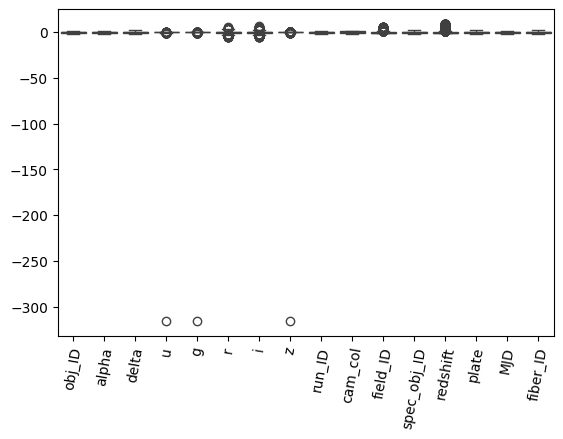

In [27]:

# YOUR CODE HERE

#Eliminamos la columna rerun_ID porque no aporta información relevante para el análisis
df_stringless = df_stringless.drop(columns=["rerun_ID"])
df.drop(columns=["rerun_ID"], inplace=True)

#Boxplot de datos para estudiar los outliers
fig = plt.figure(10)
ax = plt.gca()
plt.subplots_adjust(bottom=0.2)
plt.xticks(rotation=80)
sns.boxplot(data=df_stringless)

Parece que hay una serie de datos que están alterando el dataset y su visualización. Podemos probar a cambiarlos, sustituyéndolos por un valor medio de los datos similares para poder entender mejor el dataset

In [28]:
print(df_stringless.nsmallest(1,"u").index[0],df_stringless.nsmallest(1,"g").index[0],df_stringless.nsmallest(1,"z").index[0])

79543 79543 79543


Parece que es un único dato. Veamos cómo es y si existen otros datos pertenecientes a la misma estrella.

In [29]:
print(df.iloc[79543])
print(df[df["obj_ID"]==df_stringless.iloc[df_stringless.nsmallest(1,"u").index[0]]["obj_ID"]].index)


obj_ID         1237648703521095936.0
alpha                     224.006526
delta                      -0.624304
u                            -9999.0
g                            -9999.0
r                            18.1656
i                           18.01675
z                            -9999.0
run_ID                           752
cam_col                            2
field_ID                         537
spec_obj_ID    3731276904880250368.0
class                           STAR
redshift                    0.000089
plate                           3314
MJD                            54970
fiber_ID                         162
Name: 79543, dtype: object
RangeIndex(start=0, stop=0, step=1)


Parece que no. Tenemos varias opciones para lidiar con este objeto. Entre ellas, está la posibilidad de sacar otros cuerpos celestes escaneados en un mismo run (run_ID) y con redshift similar para obtener un valor lo más representativo posible. También existe la posibilidad de hacer una media de todos los valores de u, g, y z para asignarle a esta estrella. Voy a optar por lo primero

In [30]:
print(df[df["run_ID"]==df_stringless.iloc[df_stringless.nsmallest(1,"u").index[0]]["run_ID"]].index)
df.at[79543,"u"]

RangeIndex(start=0, stop=0, step=1)


np.float64(-9999.0)

Parece que no hay ninguna otra estrella detectada en este run. Por lo tanto, voy a optar por hacer la media de los valores. Posteriormente, procedo a visualizarlos, lo cual también ayudará a identificarlos. Realmente solo nos interesan las columnas de filtros por ahora, por lo que vamos a incluir solo esas.

<Axes: >

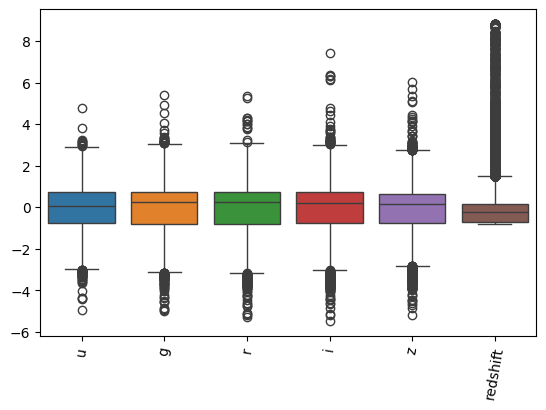

In [31]:
df.at[79543,"u"] = df["u"].mean()
df.at[79543,"g"] = df["g"].mean()
df.at[79543,"z"] = df["z"].mean()

minor_df = df[["u","g","r","i","z","redshift","class"]].copy()
#Reescalamos los datos después de eliminar los outliers
minor_df_stringless = minor_df.select_dtypes(include=["number"])
minor_df_stringless = scaler.fit_transform(minor_df_stringless)
#sns.pairplot(data = minor_df, hue="class", diag_kind="kde")

fig = plt.figure(11)
ax = plt.gca()
plt.subplots_adjust(bottom=0.2)
plt.xticks(rotation=80)
sns.boxplot(data=minor_df_stringless)

<Axes: ylabel='redshift'>

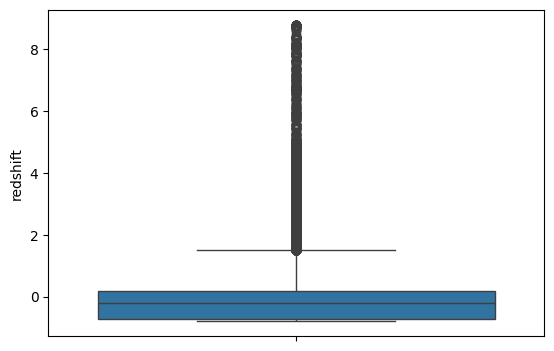

In [32]:
minor_df["alpha"] = df["alpha"]
minor_df["delta"] = df["delta"]

#sns.pairplot(data = minor_df, hue="class", diag_kind="kde")

fig = plt.figure(11)
ax = plt.gca()
plt.subplots_adjust(bottom=0.2)
plt.xticks(rotation=80)
sns.boxplot(data=df_stringless,y="redshift")

Quizá en retrospectiva fuera obvio, pero parece que el redshift será uno de los mejores categorizadores en todo el dataset. Dado el elevado tiempo de cómputo para generar estas gráficas, procedo a comentarlas. Alpha y delta siguen distribuciones similares para todas las clases, por lo que no serán utilizados como parámetros para realizar el aprendizaje.

## Dealing with unbalanced classes
There are several actions that can be taken to address an unbalanced dataset, the best approach will depend on the problem and the data itself.

The classical accuracy used in classification, when there is unbalanced classes, looses reliability. Imagine, for instance, a dataset with 99% of instances of a class A, and only 1% of class B. If we apply a dummy classifier that classifies everything as A, we will obtain an accuracy of 99%, which suggests excellent performance, but clearly this classifier will not be working correctly. For this reason accuracy is rarely used with unbalanced datasets.

One of the most commonly used metrics with unbalanced data is F1, which is defined as the harmonic mean of the precision and recall:

$F1 = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}$.

F1 is defined in a range from zero to one, with one corresponding to a perfect classification. The definition is made for binary classification problems, so it needs to be adapted to multi-label problems like the one we are dealing with. Scikit applies F1 to each class separately, obtaining several F1 values, which it then groups by means of an average. There are several methods to do this grouping. More information in [Scikit-Learn reference documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html).

Another approach to deal with an unbalanced dataset is to make it a balanced one. The most straightforward way to this is to simply undersample the majority class or oversample the minority class. A variation of the latter is to add noise to the oversampling in a controlled way, so as to bring more variety to the dataset, avoiding overlearning. In the context of Deep Learning this technique is known as "data augmentation".

<img align="center" src="https://github.com/dfbarrero/dataCourse/blob/master/assignments/stellar/smote.webp?raw=1" width="300">

More advanced techniques involve synthetically generating new instances of the minority class. For example, [SMOTE](https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/) is a technique of some sophistication and quite popular that creates new instances of the minority class by sampling the straight line joining a minority class instance with some close neighbor.

SMOTE is not supported by Sckit-Learn, we need another library named imblearn.

In [33]:
import numpy as np
import pandas as pd

from imblearn.over_sampling import SMOTE


df2 = pd.read_csv("https://github.com/dfbarrero/dataCourse/raw/master/assignments/stellar/stellar.zip")
print(df2['class'].value_counts())

x = df2.drop(['class'], axis = 1)
y = df2.loc[:,'class'].values

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


In [34]:
smote= SMOTE()
x_smote, y_smote = smote.fit_resample(x, y)

print(np.unique(y_smote, return_counts=True))

del x_smote, y_smote
del df2, x, y

(array(['GALAXY', 'QSO', 'STAR'], dtype=object), array([59445, 59445, 59445]))


## Exercise: Predictive modeling

Train a classifier to identify if a certain object is a galaxy, quasar or star. You can use any technique of your choice to deal with the unbalanced dataset and try, at least, five classifiers. Obtain the best classifier you can without sophisticated hyperparameter optimization.

In [35]:

# YOUR CODE HERE

#Utilizaremos SMOTE para balancear el dataset. Su algoritmo utiliza k-nearest neighbors para generar nuevas muestras sintéticas 
#de la clase minoritaria, por lo que probaremos knn = 3, 5 y 10 para ver cuál es el que mejor se adapta a nuestro dataset.

dict_knn = {}
x = minor_df_stringless
y = minor_df.loc[:,'class'].values
for knn in [3,5,10]:
    smote = SMOTE(k_neighbors=knn)
    x_smote, y_smote = smote.fit_resample(x, y)
    dict_knn[knn] = (x_smote, y_smote)
    

In [36]:
#Train-test split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
dict_train_test_split = {}
for knn in dict_knn.keys():
    x_smote, y_smote = dict_knn[knn]
    x_train, x_test, y_train, y_test = train_test_split(x_smote, y_smote, test_size=0.3)
    dict_train_test_split[knn] = (x_train, x_test, y_train, y_test)

In [37]:
#Dummy
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier
for knn in dict_train_test_split.keys():
    x_train, x_test, y_train, y_test = dict_train_test_split[knn]
    dummy_clf = DummyClassifier(strategy="most_frequent")
    dummy_clf.fit(x_train, y_train)
    y_pred_dummy = dummy_clf.predict(x_test)
    print(f"Accuracy for knn={knn}: {accuracy_score(y_test, y_pred_dummy)}")

Accuracy for knn=3: 0.33264798788807687
Accuracy for knn=5: 0.3315452047625278
Accuracy for knn=10: 0.3302181267639857


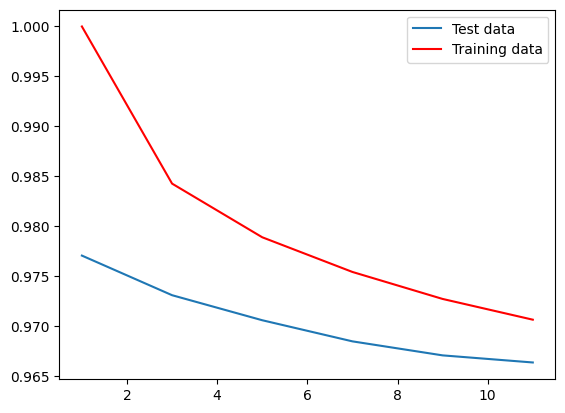

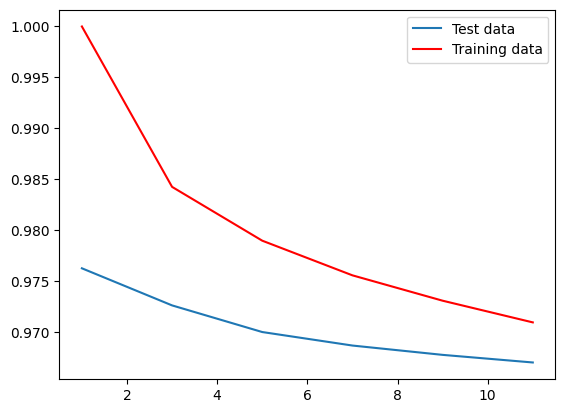

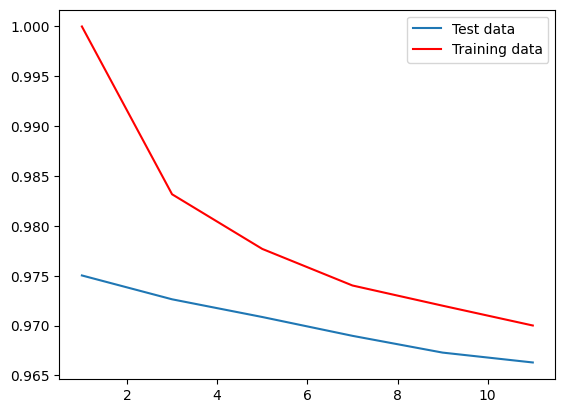

In [38]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

results_knn = []
accuracy_knn = []
for knn in dict_train_test_split.keys():
    x_train, x_test, y_train, y_test = dict_train_test_split[knn]
    for i in [1,3,5,7,9,11]:
        model = KNeighborsClassifier(n_neighbors=i)
        model.fit(x_train, y_train)
        y_model = model.predict(x_test)
        y_acc = model.predict(x_train)
        results_knn.append(accuracy_score(y_test, y_model))
        accuracy_knn.append(accuracy_score(y_train, y_acc))

    fig = plt.figure(knn)
    ax = plt.gca()
    plt.plot([1,3,5,7,9,11],results_knn)
    plt.plot([1,3,5,7,9,11],accuracy_knn,"r")
    plt.legend(["Test data", "Training data"])
    results_knn = []
    accuracy_knn = []


No se ve una diferencia muy grande entre disntintos valores de knn para el SMOTE. El mejor valor hasta ahora es SMOTE knn = 3 con knn = 1
Dado que no es razonable seguir utilizando varias configuraciones de SMOTE debido al alto tiempo de ejecución del algoritmo SVC, me voy a quedar con knn = 3 para hacer los siguientes apartados.

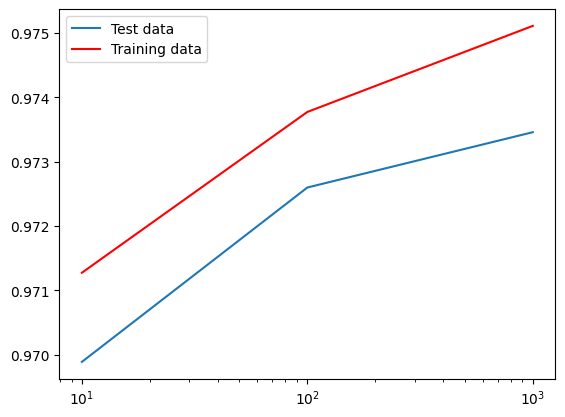

In [39]:
#SVM
from sklearn.svm import SVC

results_svm = []
accuracy_svm = []
Ce = [10,100,1000]
x_train, x_test, y_train, y_test = dict_train_test_split[3]
for i in Ce:
    model = SVC(C=i)
    model.fit(x_train, y_train)
    y_model = model.predict(x_test)
    y_acc = model.predict(x_train)
    results_svm.append(accuracy_score(y_test, y_model))
    accuracy_svm.append(accuracy_score(y_train, y_acc))

fig = plt.figure(3)
ax = plt.gca()
plt.plot(Ce,results_svm)
plt.plot(Ce,accuracy_svm,"r")
ax.set_xscale("log")
plt.legend(["Test data", "Training data"])

Parece que mejora cuando aumenta C, así que solo incluirá a partir de ahora valores de C superiores a 10

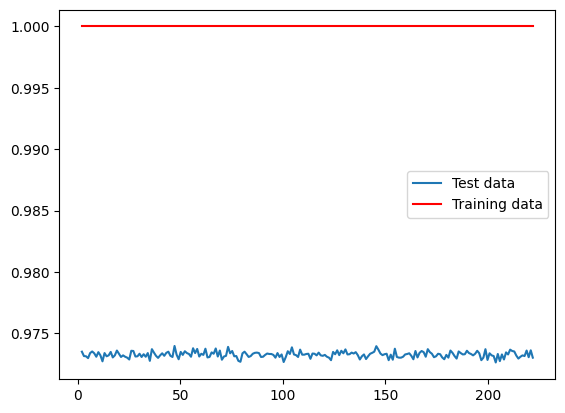

In [40]:
from sklearn.tree import DecisionTreeClassifier
results_tree = []
accuracy_tree = []
Tr = np.linspace(start=2,stop=222,num=220)
for i in Tr:
  model = DecisionTreeClassifier(max_depth=None)
  model.fit(x_train, y_train)
  y_model = model.predict(x_test)
  y_acc = model.predict(x_train)
  results_tree.append(accuracy_score(y_test, y_model))
  accuracy_tree.append(accuracy_score(y_train, y_acc))

plt.plot(Tr,results_tree)
plt.plot(Tr,accuracy_tree,"r")
plt.legend(["Test data", "Training data"])

No parece que haya mucha diferencia.

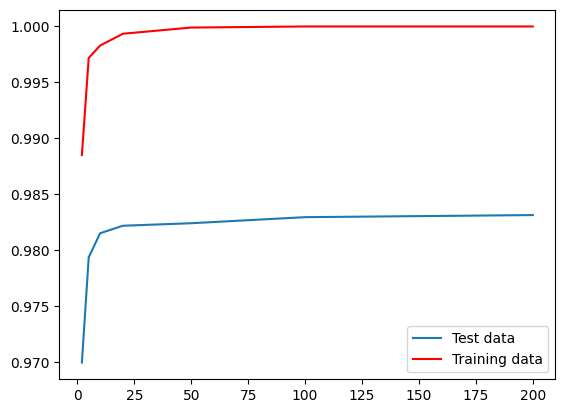

In [41]:
from sklearn.ensemble import RandomForestClassifier
results_rf = []
accuracy_rf = []
Tr2 = [2,5,10,20,50,100,200]
for i in Tr2:
  model = RandomForestClassifier(n_estimators=i)
  model.fit(x_train, y_train)
  y_model = model.predict(x_test)
  y_acc = model.predict(x_train)
  results_rf.append(accuracy_score(y_test, y_model))
  accuracy_rf.append(accuracy_score(y_train, y_acc))
  
plt.plot(Tr2,results_rf)
plt.plot(Tr2,accuracy_rf,"r")
plt.legend(["Test data", "Training data"])

Parece que este es el modelo victorioso. Veamos cuál es el máximo

In [42]:
print(max(results_rf))
print(results_rf.index(max(results_rf)))
print(Tr2[results_rf.index(max(results_rf))])


0.9831405020466907
6
200


El valor de precisión y el número de árboles cambiará entre ejecuciones. Probemos también el gradient boosting

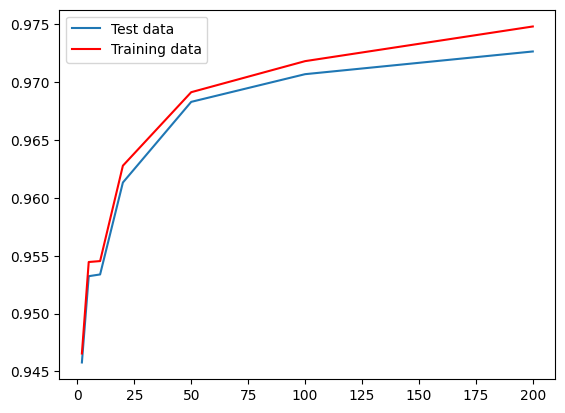

In [43]:
from sklearn.ensemble import GradientBoostingClassifier
results_gb = []
accuracy_gb = []
Tr3 = [2,5,10,20,50,100,200]
for i in Tr3:
  model = GradientBoostingClassifier(n_estimators=i)
  model.fit(x_train, y_train)
  y_model = model.predict(x_test)
  y_acc = model.predict(x_train)
  results_gb.append(accuracy_score(y_test, y_model))
  accuracy_gb.append(accuracy_score(y_train, y_acc))
  
plt.plot(Tr3,results_gb)
plt.plot(Tr3,accuracy_gb,"r")
plt.legend(["Test data", "Training data"])

No parece que ninguna estrategia sea capaz de mejorar el Random Forest Classifier. Probemos con distintos valores de SMOTE k

In [44]:
#results_rf2 = []
#accuracy_rf2 = []
#Rf2 = [20,50,100,200,500,1000]
#for knn in dict_train_test_split.keys():
#    x_train, x_test, y_train, y_test = dict_train_test_split[knn]
#    for i in Rf2:
#        model = RandomForestClassifier(n_estimators=i)
#        model.fit(x_train, y_train)
#        y_model = model.predict(x_test)
#        y_acc = model.predict(x_train)
#        results_rf2.append(accuracy_score(y_test, y_model))
#        accuracy_rf2.append(accuracy_score(y_train, y_acc))###

#    fig = plt.figure(knn)
#    ax = plt.gca()
#    plt.plot(Rf2,results_rf2)
#    plt.plot(Rf2,accuracy_rf2,"r")
#    plt.legend(["Test data", "Training data"])
#    results_rf2 = []
#    accuracy_rf2 = []

La precisión empeora con el aumento de k en SMOTE. Por lo tanto, nos quedamos con SMOTE k=3

## Hyperparameter optimization

The performance of the models depends strongly on the hyperparameters, which is more clear when dealing with real-world problems. Since performance can be quantified, we can view this problem as a pure optimization problem, for which there are a multitude of techniques in AI.

<center> Grid search <img align="center" src="https://github.com/dfbarrero/dataCourse/blob/master/assignments/stellar/grid.png?raw=1" width="300"></center>

One of the most widely used hyperparameter optimization techniques in Machine Learning is provided by the Scikit-Learn function *GridSearchCV()*, which is provided with the hyperparameters to be optimized and a range of values to be searched. The function creates a combination of hyperparameters and trains the model with each combination, returning the combination that performs best. It can apply cross-validation if required to.

In [45]:
from sklearn import svm, datasets
from sklearn.model_selection import GridSearchCV

iris = datasets.load_iris()

parameters = {'kernel':('linear', 'rbf'),
              'C':[1, 10]}

svc = svm.SVC()
clf = GridSearchCV(svc, parameters)
clf.fit(iris.data, iris.target)

print(f"Best params: {clf.best_params_}")
print(f"Best score: {clf.best_score_}")

Best params: {'C': 1, 'kernel': 'linear'}
Best score: 0.9800000000000001


Please observe that [*GridSearchCV()*](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) returns an object that contains the result of the search, but behaves like a model.

<center>Random search <img align="center" src="https://github.com/dfbarrero/dataCourse/blob/master/assignments/stellar/random.png?raw=1" width="300"></center>

Since the search space increases exponentially with the number of hyperparameters to be optimized, grid search becomes computationally intractable with some ease. A randomized search may be useful in these cases ([see *RandomizedSearchCV()*](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)), or other much more advanced methods such as bayesian optimization or even Genetic Algorithms.

## Exercise: Predictive modeling with hyperparameter optimization (optional)

Get the best classifier you can.

In [46]:

# YOUR CODE HERE

#Dado que el mejor modelo hasta ahora es el Random Forest, vamos a probar a utilizar el GridSearchCV sobre este.

random_tree = RandomForestClassifier()
parameters_rf = {'n_estimators':[20,50,100,200,500,1000],
                 'max_depth':[None,10,20,50,200]}
GSCV=GridSearchCV(random_tree, parameters_rf)
GSCV.fit(x_train, y_train)
print(f"Best params: {GSCV.best_params_}")
print(f"Best score: {GSCV.best_score_}")

Best params: {'max_depth': 200, 'n_estimators': 1000}
Best score: 0.9815034538212407


¿Qué tal el RandomizedSearchCV?

In [ ]:

from sklearn.model_selection import RandomizedSearchCV

random_tree = RandomForestClassifier()
parameters_rf = {'n_estimators':[20,50,100,200,500,1000]}
RSCV=RandomizedSearchCV(random_tree, parameters_rf)
RSCV.fit(x_train, y_train)
print(f"Best params: {RSCV.best_params_}")
print(f"Best score: {RSCV.best_score_}")


c:\Users\marco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params: {'n_estimators': 1000}
Best score: 0.9815274874682695


In [48]:
random_SVC = SVC()
parameters_SVC = {'kernel':('linear', 'rbf'),
              'C':[1,10,100,1000]}
RSCV_SVC=RandomizedSearchCV(random_SVC, parameters_SVC)
RSCV_SVC.fit(x_train, y_train)
print(f"Best params: {RSCV_SVC.best_params_}")
print(f"Best score: {RSCV_SVC.best_score_}")

c:\Users\marco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params: {'kernel': 'rbf', 'C': 1000}
Best score: 0.9739013617016358


Parece que el mejor clasificador es el RandomForest con 200 árboles, con un valor de 0.9831405020466907, aunque oscila ligeramente entre ejecuciones.